In [55]:
import random

SEED = 333
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [56]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

BASE = Path.cwd().parents[1] / 'data' / 'processed'
df = pd.read_parquet(BASE / 'dataset_consolidado.parquet')
df.index = pd.to_datetime(df.index)

# Train/test split
train = df[df.index < '2025-07-13']['precio_bolsa']
test = df[df.index >= '2025-07-13']['precio_bolsa']

print(f"Train: {len(train)} días")
print(f"Test: {len(test)} días")
print(f"Dispositivo: {'MPS (Apple Silicon)' if torch.backends.mps.is_available() else 'CPU'}")

Train: 4576 días
Test: 293 días
Dispositivo: MPS (Apple Silicon)


In [57]:
# Normalizar
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled = scaler.transform(test.values.reshape(-1, 1))

# Crear ventanas deslizantes
def crear_ventanas(data, ventana=30):
    X, y = [], []
    for i in range(len(data) - ventana):
        X.append(data[i:i+ventana])
        y.append(data[i+ventana])
    return np.array(X), np.array(y)

VENTANA = 30  # usa los últimos 30 días para predecir el siguiente

X_train, y_train = crear_ventanas(train_scaled, VENTANA)
X_test, y_test = crear_ventanas(
    np.concatenate([train_scaled[-VENTANA:], test_scaled]), VENTANA
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (4546, 30, 1)
X_test: (293, 30, 1)


In [58]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Convertir a tensores
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

# DataLoader
dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Arquitectura LSTM
class ModeloLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

modelo_lstm = ModeloLSTM().to(device)
print(modelo_lstm)
print(f"\nParámetros totales: {sum(p.numel() for p in modelo_lstm.parameters()):,}")

ModeloLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parámetros totales: 50,497


In [59]:
criterio = nn.MSELoss()
optimizador = torch.optim.Adam(modelo_lstm.parameters(), lr=0.001)

EPOCHS = 50
historial = []

for epoch in range(EPOCHS):
    modelo_lstm.train()
    perdida_epoch = 0
    for X_batch, y_batch in loader:
        optimizador.zero_grad()
        pred = modelo_lstm(X_batch)
        perdida = criterio(pred, y_batch)
        perdida.backward()
        optimizador.step()
        perdida_epoch += perdida.item()
    
    perdida_epoch /= len(loader)
    historial.append(perdida_epoch)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {perdida_epoch:.6f}")

print("Entrenamiento completo")

Epoch 10/50 — Loss: 0.000951
Epoch 20/50 — Loss: 0.000949
Epoch 30/50 — Loss: 0.000781
Epoch 40/50 — Loss: 0.000753
Epoch 50/50 — Loss: 0.000705
Entrenamiento completo


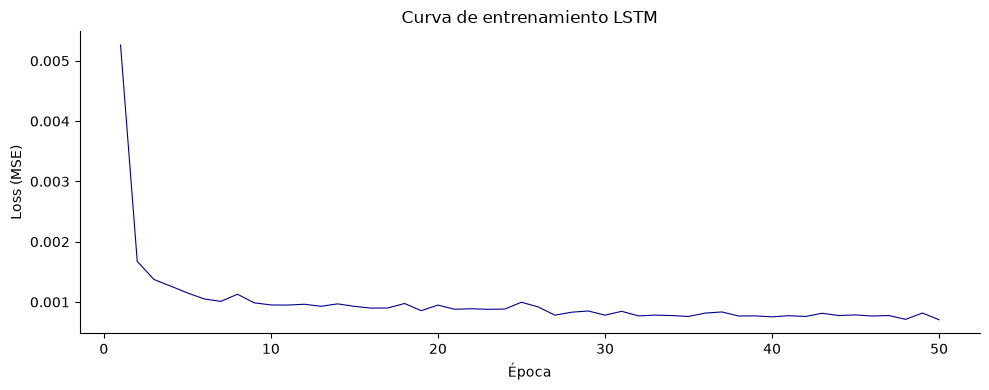

MAE:  32.36 $/kWh
RMSE: 44.81 $/kWh
MAPE: 14.74%


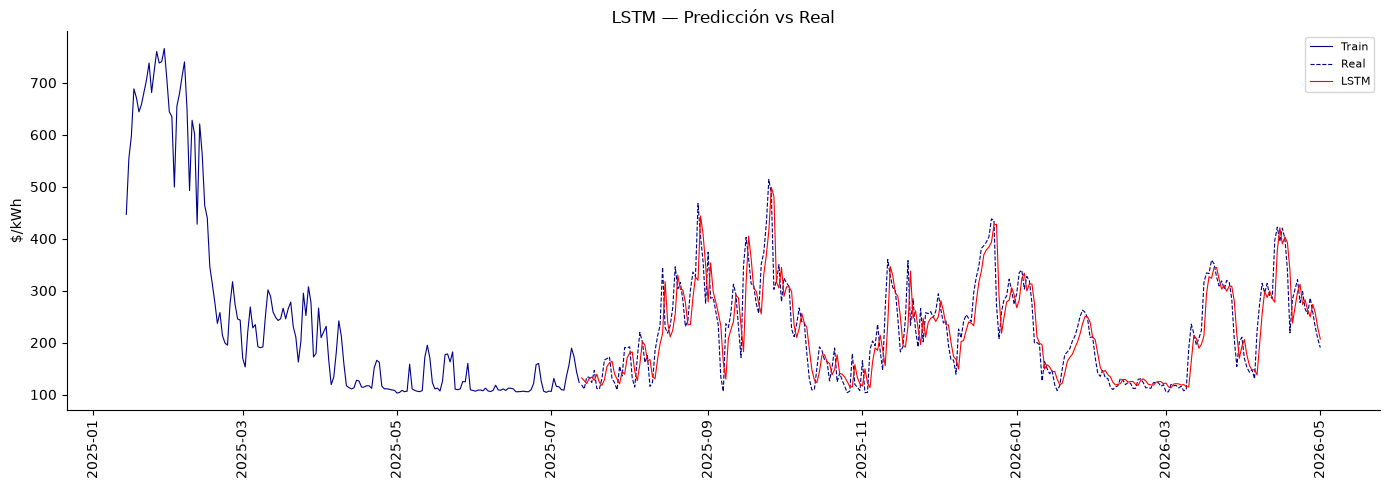

In [60]:
# Curva de entrenamiento
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, EPOCHS+1), historial, color='darkblue', linewidth=0.8)
ax.set_xlabel('Época')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Curva de entrenamiento LSTM')
sns.despine()
plt.tight_layout()
plt.show()

# Predicciones
modelo_lstm.eval()
with torch.no_grad():
    pred_scaled = modelo_lstm(X_test_t).cpu().numpy()

pred_lstm = scaler.inverse_transform(pred_scaled).flatten()
real = test.values

mae_lstm = np.mean(np.abs(real - pred_lstm))
rmse_lstm = np.sqrt(np.mean((real - pred_lstm)**2))
mape_lstm = np.mean(np.abs((real - pred_lstm) / real)) * 100

print(f"MAE:  {mae_lstm:.2f} $/kWh")
print(f"RMSE: {rmse_lstm:.2f} $/kWh")
print(f"MAPE: {mape_lstm:.2f}%")

# Gráfica predicción vs real
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train.values[-180:], color='darkblue', linewidth=0.8, label='Train')
ax.plot(test.index, real, color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(test.index, pred_lstm, color='red', linewidth=0.8, label='LSTM')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('LSTM — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()

In [61]:
PROCESSED = Path.cwd().parents[1] / 'data' / 'processed'

pred_df_dl = pd.DataFrame({
    'real': test.values,
    'lstm': pred_lstm
}, index=test.index)

pred_df_dl.to_parquet(PROCESSED / 'predicciones_dl.parquet')
print("Guardado")

Guardado


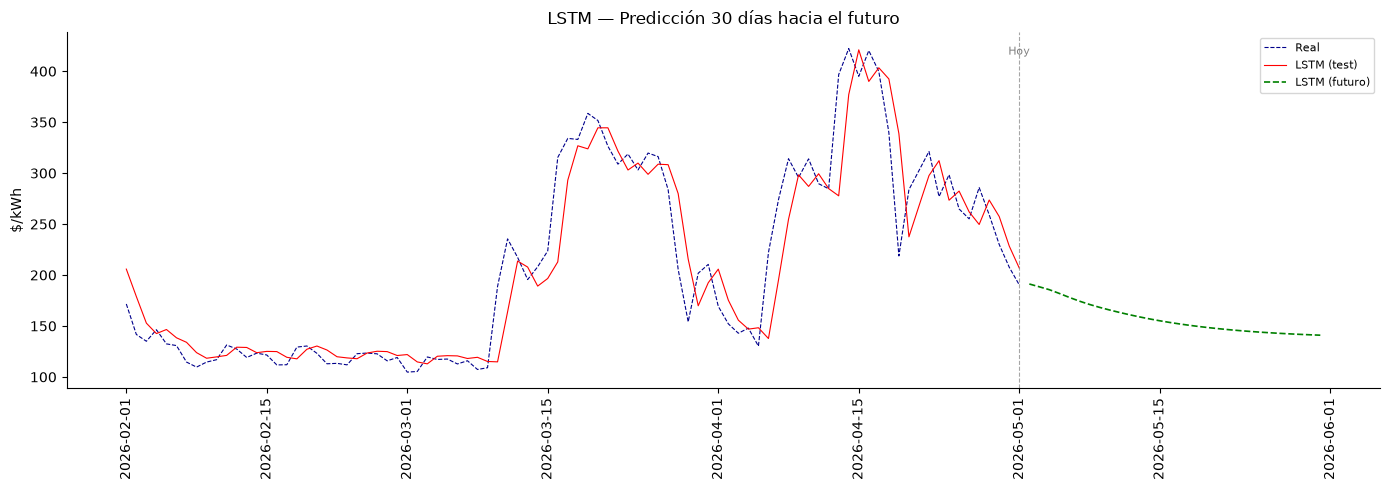


Predicción próximos 30 días:
            precio_bolsa_pred
Fecha                        
2026-05-02             191.19
2026-05-03             188.43
2026-05-04             185.59
2026-05-05             181.89
2026-05-06             177.99
2026-05-07             174.35
2026-05-08             171.13
2026-05-09             168.28
2026-05-10             165.68
2026-05-11             163.26
2026-05-12             160.99
2026-05-13             158.87
2026-05-14             156.91
2026-05-15             155.10
2026-05-16             153.46
2026-05-17             151.96
2026-05-18             150.60
2026-05-19             149.36
2026-05-20             148.23
2026-05-21             147.20
2026-05-22             146.26
2026-05-23             145.41
2026-05-24             144.65
2026-05-25             143.95
2026-05-26             143.32
2026-05-27             142.75
2026-05-28             142.23
2026-05-29             141.76
2026-05-30             141.34
2026-05-31             140.96


In [62]:
# Últimos 30 días del test como ventana inicial
ventana_inicial = test_scaled[-VENTANA:].reshape(1, VENTANA, 1)
ventana_actual = torch.FloatTensor(ventana_inicial).to(device)

predicciones_futuro = []

modelo_lstm.eval()
with torch.no_grad():
    for _ in range(30):
        pred = modelo_lstm(ventana_actual)
        predicciones_futuro.append(pred.item())
        # Actualizar ventana deslizando
        nueva_ventana = torch.cat([ventana_actual[:, 1:, :], pred.unsqueeze(0)], dim=1)
        ventana_actual = nueva_ventana

# Desnormalizar
pred_futuro = scaler.inverse_transform(
    np.array(predicciones_futuro).reshape(-1, 1)
).flatten()

# Fechas futuras
fechas_futuro = pd.date_range(
    start=test.index[-1] + pd.Timedelta(days=1), periods=30
)

# Gráfica
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index[-90:], test.values[-90:], color='darkblue', 
        linewidth=0.8, linestyle='--', label='Real')
ax.plot(test.index[-90:], pred_lstm[-90:], color='red', 
        linewidth=0.8, label='LSTM (test)')
ax.plot(fechas_futuro, pred_futuro, color='green', 
        linewidth=1.2, linestyle='--', label='LSTM (futuro)')
ax.axvline(test.index[-1], color='gray', linestyle='--', 
           linewidth=0.8, alpha=0.7)
ax.text(test.index[-1], ax.get_ylim()[1]*0.95, 'Hoy', 
        fontsize=8, color='gray', ha='center')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('LSTM — Predicción 30 días hacia el futuro')
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nPredicción próximos 30 días:")
df_futuro = pd.DataFrame({'Fecha': fechas_futuro, 'precio_bolsa_pred': pred_futuro.round(2)})
df_futuro = df_futuro.set_index('Fecha')
print(df_futuro)

In [63]:
pred_df_dl = pd.DataFrame({
    'real': test.values,
    'lstm': pred_lstm
}, index=test.index)

pred_df_dl.to_parquet(PROCESSED / 'predicciones_dl.parquet')
print("Guardado")

Guardado


In [64]:
# Arquitectura LSTM multi-output
HORIZONTE = 30  # predecir 30 días de una vez

def crear_ventanas_multi(data, ventana=30, horizonte=30):
    X, y = [], []
    for i in range(len(data) - ventana - horizonte + 1):
        X.append(data[i:i+ventana])
        y.append(data[i+ventana:i+ventana+horizonte])
    return np.array(X), np.array(y)

X_train_m, y_train_m = crear_ventanas_multi(train_scaled, VENTANA, HORIZONTE)
X_test_m, y_test_m = crear_ventanas_multi(
    np.concatenate([train_scaled[-VENTANA:], test_scaled]), VENTANA, HORIZONTE
)

print(f"X_train: {X_train_m.shape}")
print(f"y_train: {y_train_m.shape}")

X_train: (4517, 30, 1)
y_train: (4517, 30, 1)


In [65]:
class ModeloLSTMMulti(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, horizonte=30):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, horizonte)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# Tensores
X_train_mt = torch.FloatTensor(X_train_m).to(device)
y_train_mt = torch.FloatTensor(y_train_m.reshape(len(y_train_m), -1)).to(device)
X_test_mt = torch.FloatTensor(X_test_m).to(device)

dataset_m = TensorDataset(X_train_mt, y_train_mt)
loader_m = DataLoader(dataset_m, batch_size=32, shuffle=True)

modelo_lstm_multi = ModeloLSTMMulti(horizonte=HORIZONTE).to(device)
print(modelo_lstm_multi)
print(f"\nParámetros totales: {sum(p.numel() for p in modelo_lstm_multi.parameters()):,}")

ModeloLSTMMulti(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=30, bias=True)
)

Parámetros totales: 52,382


In [68]:
criterio = nn.MSELoss()
optimizador = torch.optim.Adam(modelo_lstm_multi.parameters(), lr=0.001)

EPOCHS = 200
historial_m = []

for epoch in range(EPOCHS):
    modelo_lstm_multi.train()
    perdida_epoch = 0
    for X_batch, y_batch in loader_m:
        optimizador.zero_grad()
        pred = modelo_lstm_multi(X_batch)
        perdida = criterio(pred, y_batch)
        perdida.backward()
        optimizador.step()
        perdida_epoch += perdida.item()
    
    perdida_epoch /= len(loader_m)
    historial_m.append(perdida_epoch)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {perdida_epoch:.6f}")

print("Entrenamiento completo")

Epoch 10/200 — Loss: 0.003736
Epoch 20/200 — Loss: 0.003141
Epoch 30/200 — Loss: 0.002639
Epoch 40/200 — Loss: 0.002296
Epoch 50/200 — Loss: 0.002087
Epoch 60/200 — Loss: 0.001753
Epoch 70/200 — Loss: 0.002002
Epoch 80/200 — Loss: 0.001257
Epoch 90/200 — Loss: 0.001813
Epoch 100/200 — Loss: 0.001249
Epoch 110/200 — Loss: 0.001056
Epoch 120/200 — Loss: 0.001538
Epoch 130/200 — Loss: 0.000969
Epoch 140/200 — Loss: 0.001457
Epoch 150/200 — Loss: 0.000957
Epoch 160/200 — Loss: 0.000906
Epoch 170/200 — Loss: 0.000881
Epoch 180/200 — Loss: 0.000819
Epoch 190/200 — Loss: 0.001205
Epoch 200/200 — Loss: 0.001498
Entrenamiento completo


MAE:  77.39 $/kWh
RMSE: 100.60 $/kWh
MAPE: 36.40%


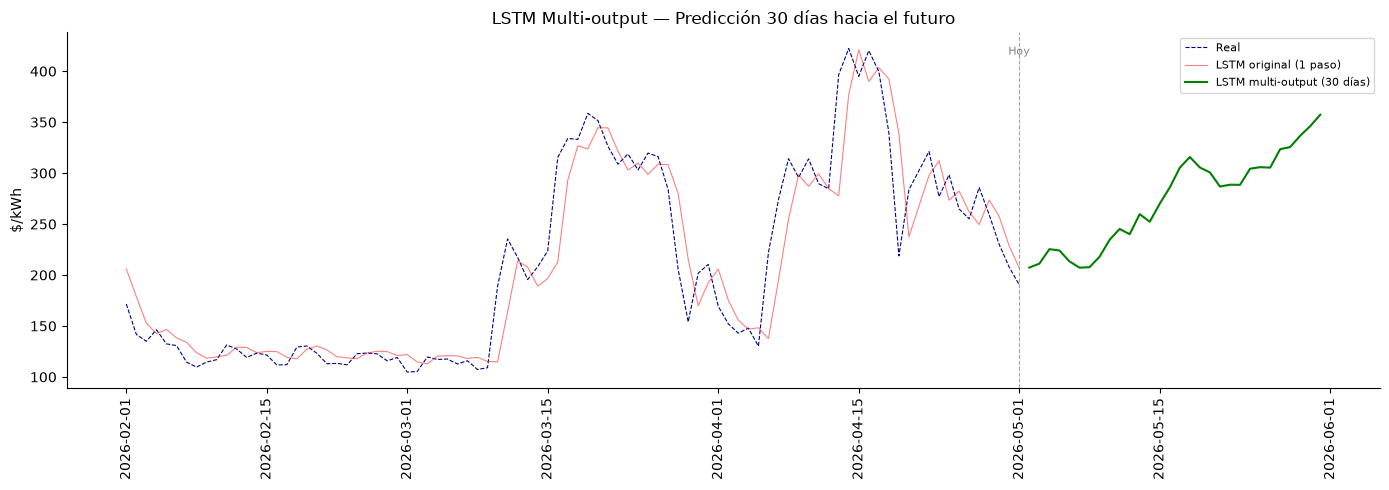

In [69]:
modelo_lstm_multi.eval()
with torch.no_grad():
    pred_scaled_m = modelo_lstm_multi(X_test_mt).cpu().numpy()

# Desnormalizar
pred_multi = scaler.inverse_transform(pred_scaled_m.reshape(-1, 1)).reshape(len(pred_scaled_m), HORIZONTE)
real_multi = scaler.inverse_transform(y_test_m.reshape(-1, 1)).reshape(len(y_test_m), HORIZONTE)

# Métricas
mae_m = np.mean(np.abs(real_multi - pred_multi))
rmse_m = np.sqrt(np.mean((real_multi - pred_multi)**2))
mape_m = np.mean(np.abs((real_multi - pred_multi) / real_multi)) * 100

print(f"MAE:  {mae_m:.2f} $/kWh")
print(f"RMSE: {rmse_m:.2f} $/kWh")
print(f"MAPE: {mape_m:.2f}%")

# Predicción futura con la última ventana del test
ultima_ventana = torch.FloatTensor(test_scaled[-VENTANA:].reshape(1, VENTANA, 1)).to(device)

modelo_lstm_multi.eval()
with torch.no_grad():
    pred_futuro_scaled = modelo_lstm_multi(ultima_ventana).cpu().numpy()

pred_futuro_m = scaler.inverse_transform(pred_futuro_scaled.reshape(-1, 1)).flatten()
fechas_futuro = pd.date_range(start=test.index[-1] + pd.Timedelta(days=1), periods=HORIZONTE)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index[-90:], test.values[-90:], color='darkblue',
        linewidth=0.8, linestyle='--', label='Real')
ax.plot(test.index[-90:], pred_lstm[-90:], color='red',
        linewidth=0.8, alpha=0.5, label='LSTM original (1 paso)')
ax.plot(fechas_futuro, pred_futuro_m, color='green',
        linewidth=1.5, label='LSTM multi-output (30 días)')
ax.axvline(test.index[-1], color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(test.index[-1], ax.get_ylim()[1]*0.95, 'Hoy', fontsize=8, color='gray', ha='center')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('LSTM Multi-output — Predicción 30 días hacia el futuro')
sns.despine()
plt.tight_layout()
plt.show()

In [70]:
# Covariables para multi-output
covariables = ['gen_termica', 'ONI', 'aportes_energia_gwh']

train_cov = df[df.index < '2025-07-13'][['precio_bolsa'] + covariables]
test_cov = df[df.index >= '2025-07-13'][['precio_bolsa'] + covariables]

# Normalizar todas las variables
scaler_multi = MinMaxScaler()
train_cov_scaled = scaler_multi.fit_transform(train_cov)
test_cov_scaled = scaler_multi.transform(test_cov)

# Ventanas con múltiples variables
def crear_ventanas_multi_cov(data, ventana=30, horizonte=30):
    X, y = [], []
    for i in range(len(data) - ventana - horizonte + 1):
        X.append(data[i:i+ventana])          # todas las variables
        y.append(data[i+ventana:i+ventana+horizonte, 0])  # solo precio
    return np.array(X), np.array(y)

X_train_mc, y_train_mc = crear_ventanas_multi_cov(train_cov_scaled, VENTANA, HORIZONTE)
X_test_mc, y_test_mc = crear_ventanas_multi_cov(
    np.concatenate([train_cov_scaled[-VENTANA:], test_cov_scaled]), VENTANA, HORIZONTE
)

print(f"X_train: {X_train_mc.shape}")
print(f"y_train: {y_train_mc.shape}")

X_train: (4517, 30, 4)
y_train: (4517, 30)


In [72]:
# Tensores
X_train_mct = torch.FloatTensor(X_train_mc).to(device)
y_train_mct = torch.FloatTensor(y_train_mc).to(device)
X_test_mct = torch.FloatTensor(X_test_mc).to(device)

dataset_mc = TensorDataset(X_train_mct, y_train_mct)
loader_mc = DataLoader(dataset_mc, batch_size=32, shuffle=True)

# Modelo con 4 variables de entrada
class ModeloLSTMMultiCov(nn.Module):
    def __init__(self, input_size=4, hidden_size=128, num_layers=2, horizonte=30):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, horizonte)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

modelo_lstm_mc = ModeloLSTMMultiCov().to(device)

criterio = nn.MSELoss()
optimizador = torch.optim.Adam(modelo_lstm_mc.parameters(), lr=0.001)

# Scheduler — reduce lr a la mitad si la pérdida no mejora en 10 épocas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador, mode='min', factor=0.5, patience=10
)

EPOCHS = 200
historial_mc = []

for epoch in range(EPOCHS):
    modelo_lstm_mc.train()
    perdida_epoch = 0
    for X_batch, y_batch in loader_mc:
        optimizador.zero_grad()
        pred = modelo_lstm_mc(X_batch)
        perdida = criterio(pred, y_batch)
        perdida.backward()
        optimizador.step()
        perdida_epoch += perdida.item()
    
    perdida_epoch /= len(loader_mc)
    historial_mc.append(perdida_epoch)
    scheduler.step(perdida_epoch)
    
    if (epoch + 1) % 10 == 0:
        lr_actual = optimizador.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {perdida_epoch:.6f} — lr: {lr_actual:.6f}")

print("Entrenamiento completo")

Epoch 10/200 — Loss: 0.003953 — lr: 0.001000
Epoch 20/200 — Loss: 0.002909 — lr: 0.001000
Epoch 30/200 — Loss: 0.002062 — lr: 0.001000
Epoch 40/200 — Loss: 0.001703 — lr: 0.001000
Epoch 50/200 — Loss: 0.001253 — lr: 0.001000
Epoch 60/200 — Loss: 0.000999 — lr: 0.001000
Epoch 70/200 — Loss: 0.001132 — lr: 0.001000
Epoch 80/200 — Loss: 0.000731 — lr: 0.001000
Epoch 90/200 — Loss: 0.000623 — lr: 0.001000
Epoch 100/200 — Loss: 0.000581 — lr: 0.001000
Epoch 110/200 — Loss: 0.000489 — lr: 0.001000
Epoch 120/200 — Loss: 0.000448 — lr: 0.001000
Epoch 130/200 — Loss: 0.000426 — lr: 0.001000
Epoch 140/200 — Loss: 0.000385 — lr: 0.001000
Epoch 150/200 — Loss: 0.000378 — lr: 0.001000
Epoch 160/200 — Loss: 0.000357 — lr: 0.001000
Epoch 170/200 — Loss: 0.000292 — lr: 0.000500
Epoch 180/200 — Loss: 0.000279 — lr: 0.000500
Epoch 190/200 — Loss: 0.000267 — lr: 0.000500
Epoch 200/200 — Loss: 0.000258 — lr: 0.000500
Entrenamiento completo


In [73]:
modelo_lstm_mc.eval()
with torch.no_grad():
    pred_scaled_mc = modelo_lstm_mc(X_test_mct).cpu().numpy()

# Desnormalizar solo la columna de precio (índice 0)
scaler_precio = MinMaxScaler()
scaler_precio.fit(train_cov[['precio_bolsa']])

pred_mc = scaler_precio.inverse_transform(pred_scaled_mc.reshape(-1, 1)).reshape(len(pred_scaled_mc), HORIZONTE)
real_mc = scaler_precio.inverse_transform(y_test_mc.reshape(-1, 1)).reshape(len(y_test_mc), HORIZONTE)

mae_mc = np.mean(np.abs(real_mc - pred_mc))
rmse_mc = np.sqrt(np.mean((real_mc - pred_mc)**2))
mape_mc = np.mean(np.abs((real_mc - pred_mc) / real_mc)) * 100

print(f"MAE:  {mae_mc:.2f} $/kWh")
print(f"RMSE: {rmse_mc:.2f} $/kWh")
print(f"MAPE: {mape_mc:.2f}%")

MAE:  99.33 $/kWh
RMSE: 128.86 $/kWh
MAPE: 44.46%


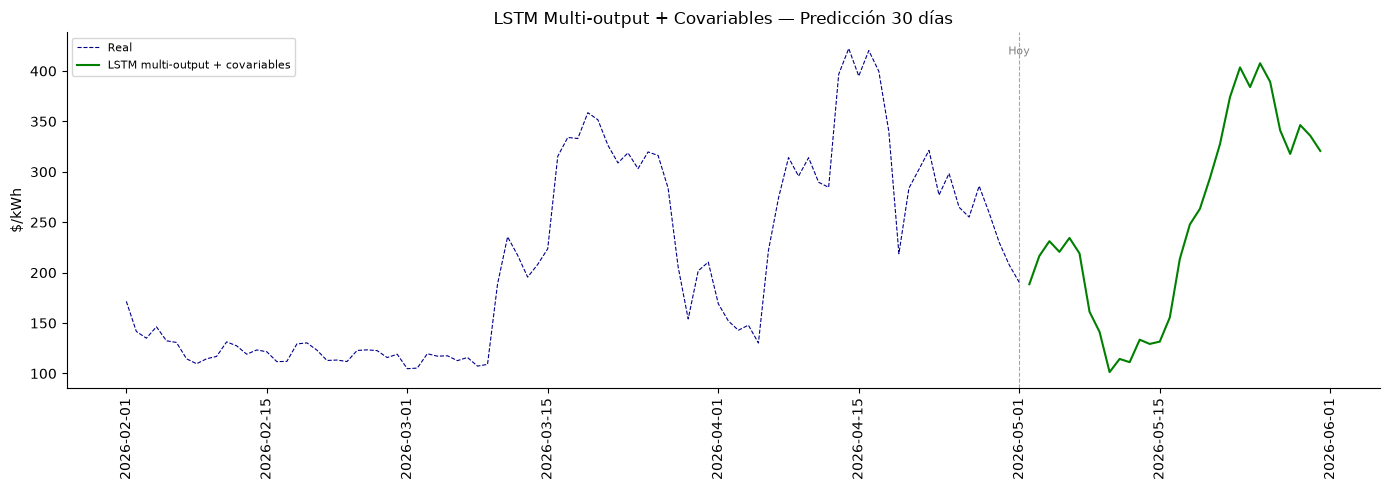

In [74]:
# Predicción futura
ultima_ventana_mc = torch.FloatTensor(
    test_cov_scaled[-VENTANA:].reshape(1, VENTANA, 4)
).to(device)

modelo_lstm_mc.eval()
with torch.no_grad():
    pred_futuro_scaled_mc = modelo_lstm_mc(ultima_ventana_mc).cpu().numpy()

pred_futuro_mc = scaler_precio.inverse_transform(
    pred_futuro_scaled_mc.reshape(-1, 1)
).flatten()

fechas_futuro = pd.date_range(
    start=test_cov.index[-1] + pd.Timedelta(days=1), periods=HORIZONTE
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_cov.index[-90:], test_cov['precio_bolsa'][-90:], 
        color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(fechas_futuro, pred_futuro_mc, color='green',
        linewidth=1.5, label='LSTM multi-output + covariables')
ax.axvline(test_cov.index[-1], color='gray', linestyle='--', 
           linewidth=0.8, alpha=0.7)
ax.text(test_cov.index[-1], ax.get_ylim()[1]*0.95, 'Hoy',
        fontsize=8, color='gray', ha='center')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('LSTM Multi-output + Covariables — Predicción 30 días')
sns.despine()
plt.tight_layout()
plt.show()